In [39]:
#imports
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import sys
import os
from astropy.cosmology import Planck18 as cosmo
import ast




In [41]:
# --- User toggle ---
Cristina = True
Shar = not Cristina 

# --- System Configurations ---

if Cristina:
    print("[CONFIG] Using Cristina's local MacBook setup")
    sys.path.insert(0, "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/Users/andradenebula/rubin_sim_data"
    db_dir = "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub"
    base_dir = '/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output'

elif Shar:
    print("[CONFIG] Using Shar's Dirac server setup")
    sys.path.insert(0, "/lustre/lrspec/metrics")
    sys.path.insert(0, "/home/3155/metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/lustre/lrspec/metrics/rubin_sim_data"
    db_dir = "/lustre/lrspec/metrics"
    base_dir = '/lustre/lrspec/metrics/results'

# Shared config
sys.path.append(os.path.abspath(".."))  # For shared_utils


[CONFIG] Using Cristina's local MacBook setup


In [45]:
# this happens twice because idk why but it only works like that
# ...you still have to run it twice if it gives warnings
# C: Make sure you save your metric file before running. 

import os, sys, importlib

# Adjust if your notebook is elsewhere
repo_root = os.path.abspath("..")
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

metric_filename = "local_InteractingHPSN"  # module name (no .py)
s_u = "shared_utils"                       # shared utils module (no .py)

def _reload(modname):
    """Hard reload a module by name."""
    importlib.invalidate_caches()
    if modname in sys.modules:
        del sys.modules[modname]
    mod = importlib.import_module(modname)
    return importlib.reload(mod)

# --- Reload metric module ---
metric = _reload(metric_filename)

# --- Reload shared_utils module ---
shared_utils = _reload(s_u)

print(f"[INFO] Loaded metric module: {metric_filename}")
try:
    print("       ->", metric.__file__)
except Exception:
    pass

print(f"[INFO] Loaded shared_utils module")
try:
    print("       ->", shared_utils.__file__)
except Exception:
    pass




[INFO] Loaded metric module: local_InteractingHPSN
       -> /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/InteractingHPSN/local_InteractingHPSN.py
[INFO] Loaded shared_utils module
       -> /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/shared_utils.py


In [71]:
# --- Science configuration ---
family = "icn"         # choose: "icn" or "ibn"

# Volumetric rate (events / Mpc^3 / yr)
# Icn ~ (0.005–0.05)% of CCSN; if CCSN ~1e-4 -> ~5e-9 -> 5e-8
# Ibn ~ ~1% of CCSN -> ~1e-6
rate_density = 5e-9 if family == "icn" else 1e-6

# Distance / redshift bounds for the population
z_min, z_max = 0.002, 0.25     # tweak per science case
d_min, d_max = None, None

# Extinction & K-corrections
use_extinction   = True
use_kcorrect     = True
k_correct_type   = "blackbody"           # or "powerlaw"
k_correct_arg    = 15000                 # Kelvin for blackbody; α for powerlaw

# Template generation
num_lightcurves      = 1000
generate_new_templates = True   # True if you change LC class; set False for reuse
generate_new_pop       = True   # True to force regenerating population

# Survey window (days since survey start)
t_start, t_end = 1, 3652

# Cadences to test (filenames in your OpSim DB dir, no .db suffix)
cadences = ['four_roll_v4.3.1_10yrs']    # add more if desired

# Paths
base_dir = os.path.abspath(os.path.join(repo_root, "output"))
db_dir = "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub"
cadences = ["four_roll_v4.3.1_10yrs"]  # keep just the stem
os.makedirs(base_dir, exist_ok=True)

# after reloading modules
su = shared_utils

# sanity check
assert hasattr(su, "build_filenames"), "shared_utils has no build_filenames()"


# --- Filenames & storage ---
science_case = f"InteractingHPSN_{family.upper()}"

templates_file, pop_file, df_file, storage_dir, summary_filename = su.build_filenames(
    testname=None,
    testname_metric_only=None,
    science_case=science_case,
    rate_density=rate_density,
    z_min=z_min, z_max=z_max,
    d_min=d_min, d_max=d_max,
    ignore_triples=False,
    use_extinction=use_extinction,
    use_kcorrect=use_kcorrect,
    base_dir=base_dir
)
os.makedirs(storage_dir, exist_ok=True)



InteractingHPSN_ICN_den_5e-09_d_None-None_Mpc_z_0.002-0.25_ext_True_kcor_True_None


In [73]:
# --- Load or generate LC templates ---
LC_Class = metric.LC_Icn if family == "icn" else metric.LC_Ibn

shared_lc_model = su.load_or_generate_templates(
    LC=LC_Class,
    templates_file=templates_file,
    num_samples=200,
    num_lightcurves=num_lightcurves,
    generate_new=generate_new_templates
)


[INFO] Generating 1000 light curve templates.
Saved synthetic light curve templates to /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/InteractingHPSN_ICN/InteractingHPSN_ICN_den_5e-09_d_None-None_Mpc_z_0.002-0.25_ext_True_kcor_True_None_templates.pkl
Loaded Icn templates from /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/InteractingHPSN_ICN/InteractingHPSN_ICN_den_5e-09_d_None-None_Mpc_z_0.002-0.25_ext_True_kcor_True_None_templates.pkl


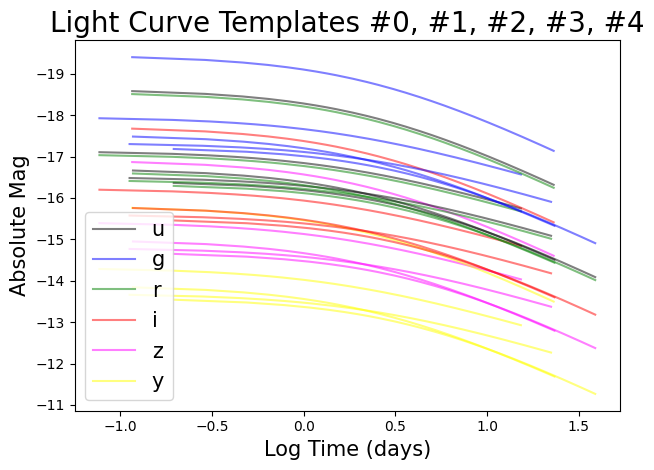

In [75]:
#plot light curves from pkl file if desired
shared_utils.plot_template_lcs(templates_file, num=5, use_log_time=True, plot_overlap=True)

[INFO] Generating population and saving to /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/InteractingHPSN_ICN/InteractingHPSN_ICN_den_5e-09_d_None-None_Mpc_z_0.002-0.25_ext_True_kcor_True_None_population.pkl
[INFO] z_min = 0.00200 -> d_min = 8.857595861807285 Mpc
[INFO] z_max = 0.25000 -> d_max = 1040.877290166713010 Mpc
Simulated 267 events using rate_density = 5.0e-09
Len ra before masking:  267


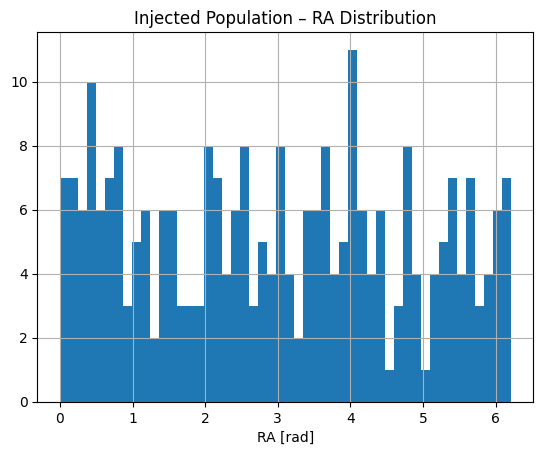

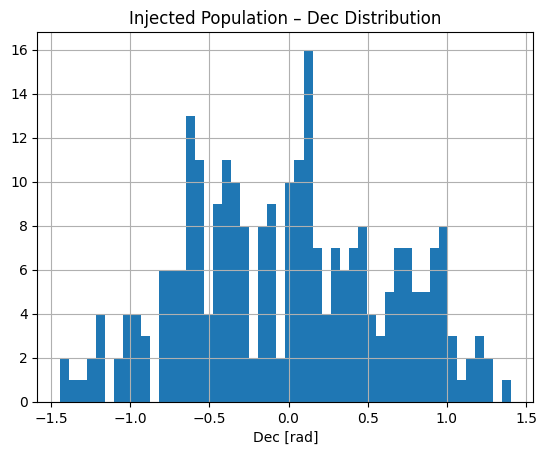

initial peak times:  [ 561.84250585  422.65422244   78.21140764  203.24863886  638.61601039
  195.89743602 2159.26607262 2486.28873734 1438.14479789 1161.98549497
 1843.02529137 3195.6430441  3108.48156953  159.72745141  663.65069344
  865.3555244   911.51403936 2086.57041151 1520.77411624  180.82679186
 1365.06521952 1913.22201577  372.2041175  3043.95717988  190.71277446
 3377.59766378  362.86207991 3080.89214828 3296.58662848 3577.41255482
 2929.19648888 2846.87250136 2346.70644066 2845.11569056  492.25011292
 1958.18439924 1878.42769907 3131.99589819 1690.68048378 1406.96175026
 2336.04550329  973.8575722   511.29446839 1745.72992746 1523.06308474
  850.11285287 1342.78561873 1338.69883432 1196.68630567 1386.42335508
 2504.64895426 1084.89600866 3465.28029044 3346.58661933 1756.80397372
 1199.84675947 1955.87241767 3099.09434451 2383.59638038 2937.83456383
 1945.96902992 2311.78226446 1053.05614738 2684.09493559  739.9791695
 2537.70796832 3143.48531846  483.30745899 2244.10043272 

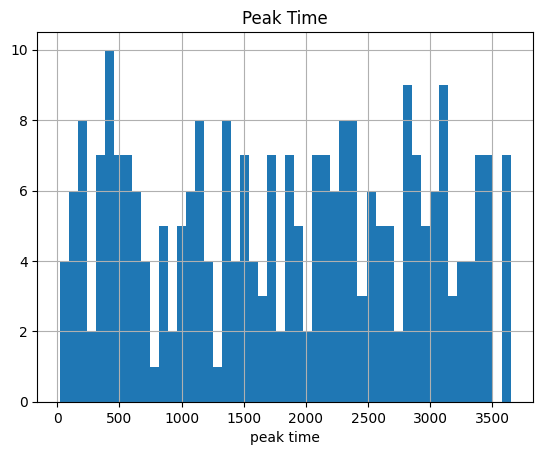

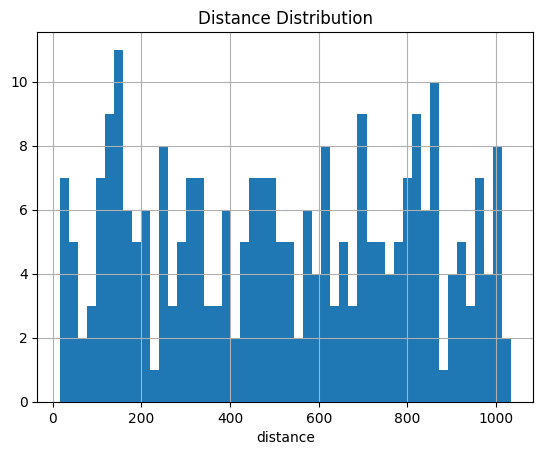

[DEBUG] coords.dec[:5]: [ 55.10793643 -33.51005607 -18.20995686   7.18075578   7.78271439] deg
[DEBUG] coords.dec.unit: deg


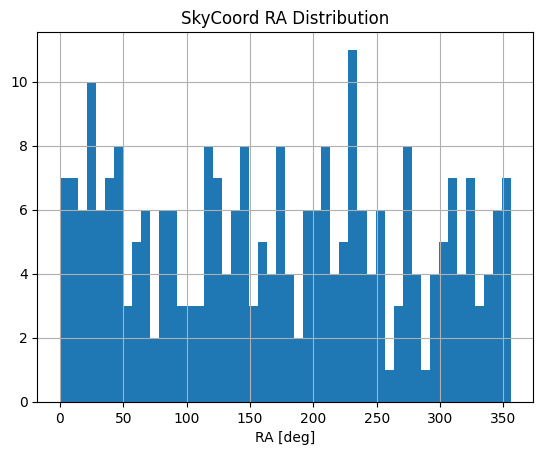

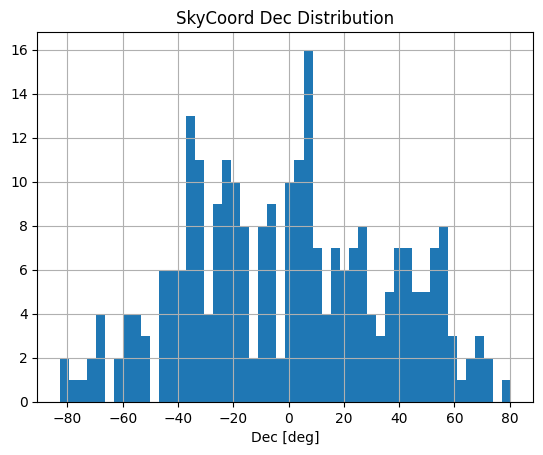

[INFO] Saved atomically to /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/InteractingHPSN_ICN/InteractingHPSN_ICN_den_5e-09_d_None-None_Mpc_z_0.002-0.25_ext_True_kcor_True_None_population.pkl
DEBUG: type(peak_times) = <class 'numpy.ndarray'>
DEBUG: shape(peak_times) = (267,)


In [77]:
# --- Load or generate population ---
slicer = su.load_or_generate_population(
    use_extinction=use_extinction,
    pop_file=pop_file,
    lc_model=shared_lc_model,
    t_start=t_start, t_end=t_end,
    d_min=d_min, d_max=d_max,
    z_min=z_min, z_max=z_max,
    num_lightcurves=num_lightcurves,
    gal_lat_cut=None,
    rate_density=rate_density,
    generate_new=generate_new_pop,
    make_debug_plots=True,
    use_kcorrect=use_kcorrect,
    k_correct_type=k_correct_type,
    k_correct_arg=k_correct_arg
)


In [78]:
shared_utils.get_kcorrection_powerlaw(np.array([1,4]), 'y', spectral_index=-.75)

array([1.31700623, 3.05799377])

In [81]:
shared_utils.get_kcorrection_blackbody(np.array([.05,1,2,4]), 'u', temperature=10000)

array([ 0.10874672,  2.73033789,  6.06364269, 13.38102463])

In [83]:
import importlib, shared_utils
importlib.reload(shared_utils)


<module 'shared_utils' from '/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/shared_utils.py'>

## All 10 years


--- Running four_roll_v4.3.1_10yrs ---
(2,)
[<local_InteractingHPSN.IbnIcnDetect_Metric object at 0x32e845a10>, <local_InteractingHPSN.IbnIcnCharacterizeMetric object at 0x1072aa710>]
                                             Sum                     run  \
four_roll_v4.3.1_10yrs_IbnIcnDetect_Metric  16.0  four_roll_v4.3.1_10yrs   

                                            n_events_full_sky  
four_roll_v4.3.1_10yrs_IbnIcnDetect_Metric                267  


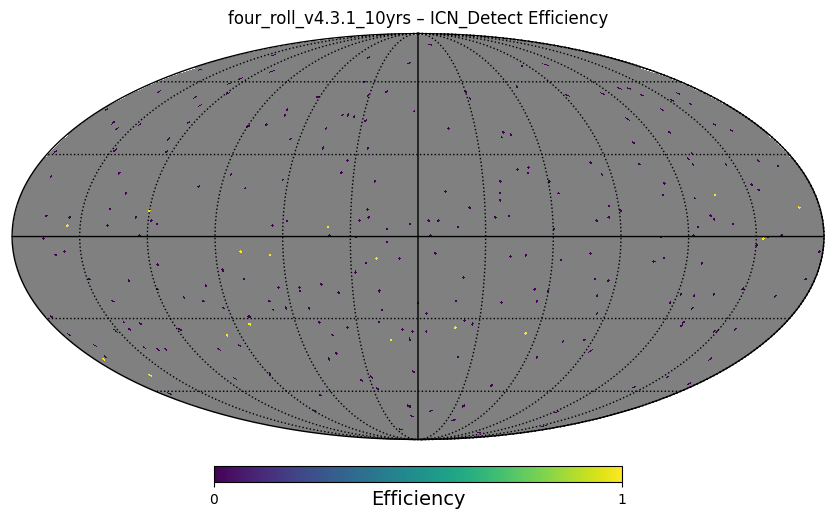

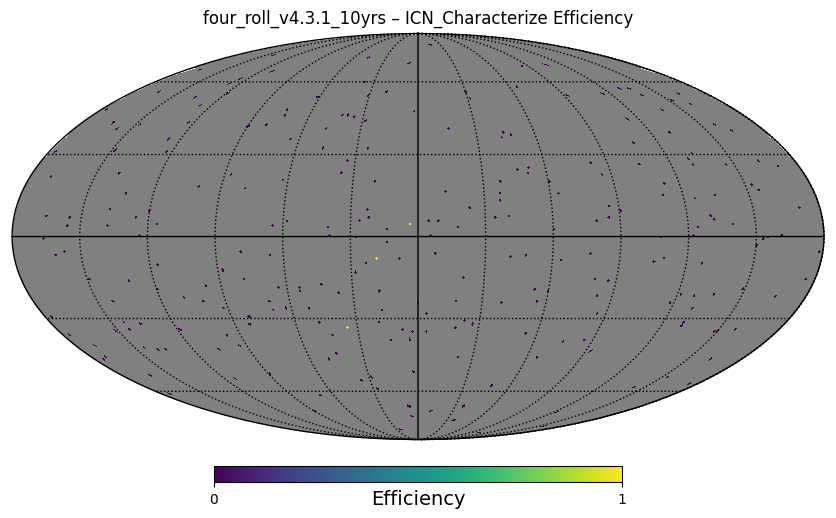

[CLEANUP] Removing temp directory: /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/InteractingHPSN_ICN/Metric_temp_four_roll_v4.3.1_10yrs
saved summary to  /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/InteractingHPSN_ICN/InteractingHPSN_ICN_den_5e-09_d_None-None_Mpc_z_0.002-0.25_ext_True_kcor_True_None_None_multi_summary.csv


,Sum,run,n_events_full_sky
four_roll_v4.3.1_10yrs_IbnIcnDetect_Metric,16.0,four_roll_v4.3.1_10yrs,267
four_roll_v4.3.1_10yrs_IbnIcnCharacterizeMetric,4.0,four_roll_v4.3.1_10yrs,267


In [86]:
# --- Assemble metrics ---
multi = metric.get_multi_metrics(
    lc_model=shared_lc_model,
    include=None,                     # or ['icn_detect'] / ['ibn_char'] etc.
    use_extinction=use_extinction,
    use_kcorrect=use_kcorrect,
    k_correct_type=k_correct_type,
    k_correct_arg=k_correct_arg,
    family=family
)
# Example (optional): force metrics to consider only specific filters
# for m in multi:
#     m.filter_include = ['g','r']

# --- Run metrics across cadences ---
summary_df = su.run_multi_metrics(
    multi_metrics=multi,
    slicer=slicer,
    cadences=cadences,
    shared_lc_model=shared_lc_model,
    db_dir=db_dir,
    storage_dir=storage_dir,
    summary_filename=summary_filename,
    ignore_triples=False,
    plot=True,
    clean_temp=True,
    use_extinction=use_extinction,
    use_kcorrect=use_kcorrect
)
summary_df.tail()


In [88]:
cols = ["sid",
        "injected_peak_ebv_mag_r",
        "injected_peak_ebv_mag_r_cadence",
        "eval_peak_mag"]
print(df_obs[cols].head())

print("Residuals vs cadence-aware (should ~0):",
      np.nanmedian(df_obs["eval_peak_mag"] - df_obs["injected_peak_ebv_mag_r_cadence"]))

print("Cadence penalty (cadence − global):",
      np.nanmedian(df_obs["injected_peak_ebv_mag_r_cadence"] - df_obs["injected_peak_ebv_mag_r"]))


NameError: name 'df_obs' is not defined

In [90]:

#choose what to run in run_multi_metrics
# we can remove historical if we want
multi_metrics = metric.get_multi_metrics(shared_lc_model, include=['detect','characterize'], use_extinction=use_extinction, use_kcorrect=use_kcorrect, k_correct_type=k_correct_type, k_correct_arg=k_correct_arg)


# Apply consistent diagnostics knobs
for m in multi_metrics:
    m.diag_store = True
    m.diag_sample_rate = 0.01
    m.diag_per_event_cap = 30
    m.diag_min_snr = 3
    m.diag_max_mag = None



In [92]:
summary_df_1 = shared_utils.run_multi_metrics(multi_metrics, 
                                              slicer, cadences, shared_lc_model, 
                                              db_dir, storage_dir, 
                                              summary_filename=summary_filename, ignore_triples=False, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)

NameError: name 'clean_temp' is not defined

In [94]:
summary_df_1

NameError: name 'summary_df_1' is not defined

In [96]:
import pickle
with open(pop_file, 'rb') as f:
    sp = pickle.load(f)
missing = [f'peak_app_mag_ebv_{f}' for f in ('u','g','r','i','z','y') if f'peak_app_mag_ebv_{f}' not in sp]
print("Missing peak columns:", missing or "None — all present")


Missing peak columns: None — all present


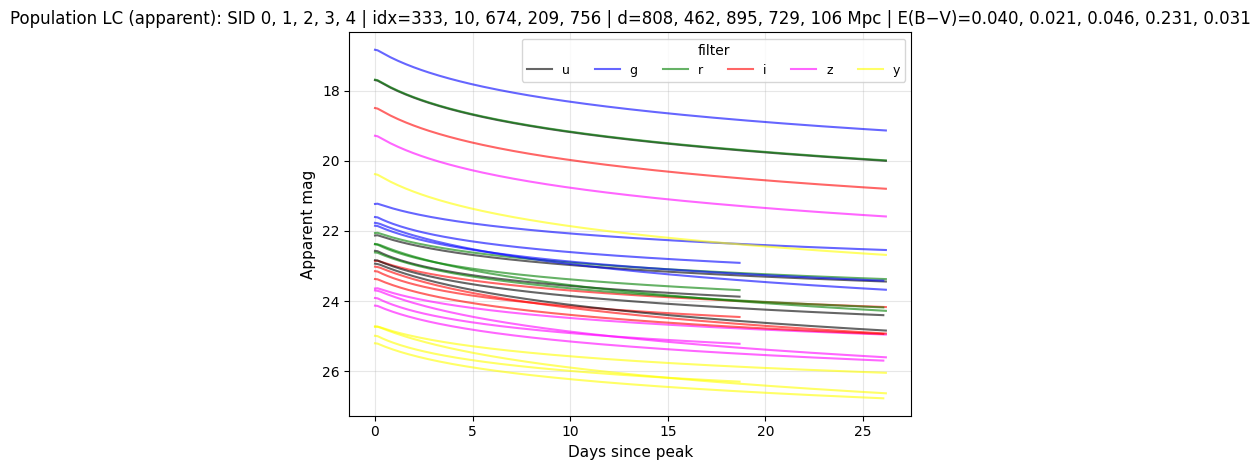

In [106]:
shared_utils.plot_population_lcs(
    pop_file=pop_file,
    lc_model=shared_lc_model,   # or pass templates_file=templates_file
    fast_peaks=False,
    use_kcorrect=use_kcorrect,
    k_correct_type=k_correct_type,
    k_correct_arg=k_correct_arg,
    num=5,
    days_before=0.0,            # see note below
    days_after=100.0,
    use_log_time=False,
    overlap=True
)
